In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
# Parameters
input_size = 4
hidden_size = 4
num_layers = 1
batch_size = 1
seq_len = 5

In [3]:
# Prepare Data
idx2char = ['e', 'h', 'l', 'o']
# The input sequence is 'hello'
x_data = [1, 0, 2, 2, 3]
# The output sequence is 'ohlol'
y_data = [3, 1, 2, 3, 2]

one_hot_lookup = [[1, 0, 0, 0],
                  [0, 1, 0, 0],
                  [0, 0, 1, 0],
                  [0, 0, 0, 1]]
# Convert indices into one-hot vector
x_one_hot = [one_hot_lookup[x] for x in x_data]

# Constructing input sequences and labels
inputs = torch.Tensor(x_one_hot).view(seq_len, batch_size, input_size)
labels = torch.LongTensor(y_data)

In [4]:
# Design Model
class Model(torch.nn.Module):
    def __init__(self, input_size, hidden_size, batch_size, num_layers):
        super(Model, self).__init__()
        # Initial the parameters
        self.num_layers = num_layers
        self.batch_size = batch_size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.rnn = torch.nn.RNN(input_size=self.input_size, hidden_size=self.hidden_size, num_layers=num_layers)
        
    def forward(self, input):
        # Shape of hidden: (numLayers, bacthSize, hiddenSize)
        hidden = torch.zeros(self.num_layers, self.batch_size, self.hidden_size)
        out, _ = self.rnn(input, hidden)
        # Reshape out to: (seqLen * batchSize, hiddenSize)
        return out.view(-1, self.hidden_size)
    
net = Model(input_size, hidden_size, batch_size, num_layers)

In [5]:
# Loss and Optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.05)

In [6]:
epoch_list = []
loss_list = []

In [7]:
# Training Cycle
for epoch in range(15):
    optimizer.zero_grad()
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    
    _, idx = outputs.max(dim=1)
    idx = idx.data.numpy()
    print('Predicted: ', ''.join([idx2char[x] for x in idx]), end='')
    print(', Epoch [%d/15] loss=%.3f' % (epoch+1, loss.item()))
    
    epoch_list.append(epoch)
    loss_list.append(loss.item())

Predicted:  eeeee, Epoch [1/15] loss=1.911
Predicted:  eeeee, Epoch [2/15] loss=1.737
Predicted:  eeeee, Epoch [3/15] loss=1.557
Predicted:  eeeee, Epoch [4/15] loss=1.372
Predicted:  eheoe, Epoch [5/15] loss=1.198
Predicted:  ohool, Epoch [6/15] loss=1.052
Predicted:  ohool, Epoch [7/15] loss=0.939
Predicted:  ohool, Epoch [8/15] loss=0.854
Predicted:  ohool, Epoch [9/15] loss=0.787
Predicted:  ohlol, Epoch [10/15] loss=0.734
Predicted:  ohlol, Epoch [11/15] loss=0.691
Predicted:  ohlol, Epoch [12/15] loss=0.654
Predicted:  ohlol, Epoch [13/15] loss=0.623
Predicted:  ohlol, Epoch [14/15] loss=0.596
Predicted:  ohlol, Epoch [15/15] loss=0.573


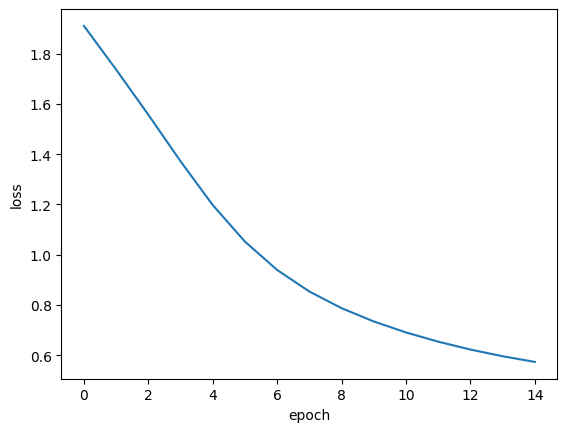

In [8]:
plt.plot(epoch_list, loss_list)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()